# <center>Clustering Analysis<center>

## Instructions
Use generic coding style unless hard-coded values are really necessary.<br>
Your code must be efficient and use self-explanatory naming.<br>
Use appropriate Python library methods for each task instead of using loops.<br>
Run your entire code and save. Then submit this <b>saved</b> copy.

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


## Read Data

In [ ]:

DATA_PATH = "student_exam_scores.csv"

df = pd.read_csv(DATA_PATH)


rename_map = {
    "Hours_Studied": "hours_studied",
    "Sleep_Hours": "sleep_hours",
    "Attendance": "attendance_percent",
    "Prev_Scores": "previous_scores",
    "Exam_Score": "exam_score",
}
df = df.rename(columns=rename_map)


expected_cols = [
    "student_id",
    "hours_studied",
    "sleep_hours",
    "attendance_percent",
    "previous_scores",
    "exam_score",
]
df = df[[c for c in expected_cols if c in df.columns]]

display(df.head(10))
display(df.shape)


,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3
5,S006,8.4,5.1,58.5,75,35.7
6,S007,10.8,6.0,54.2,88,37.9
7,S008,2.0,4.3,75.8,55,18.3
8,S009,5.6,5.9,81.6,84,34.7
9,S010,1.3,8.9,66.8,70,24.7


(200, 6)

## Visual Exploration of Data

### Histograms

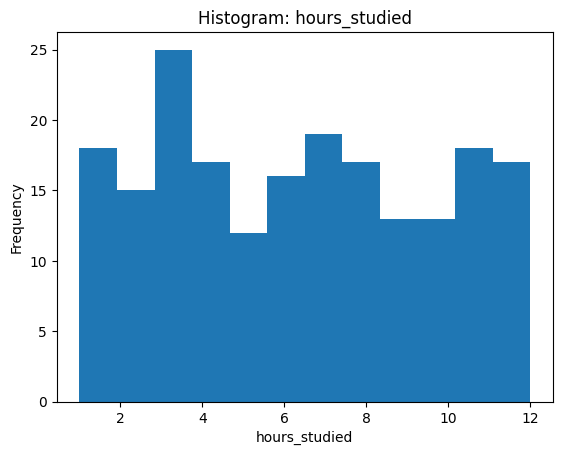

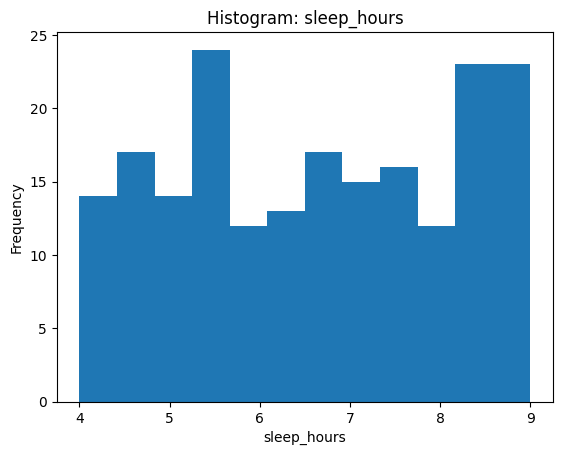

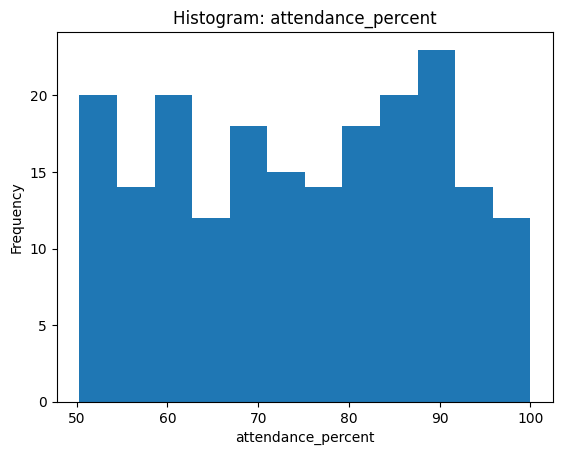

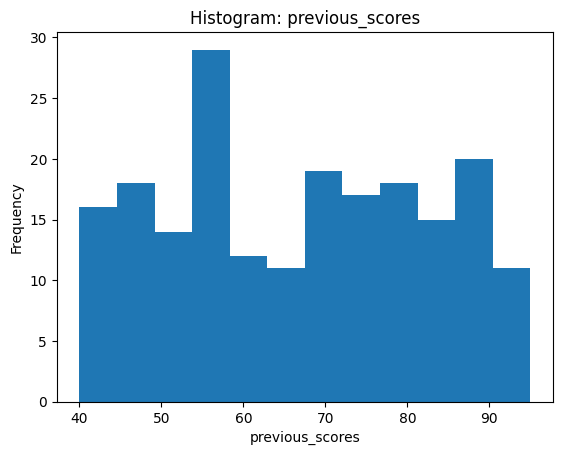

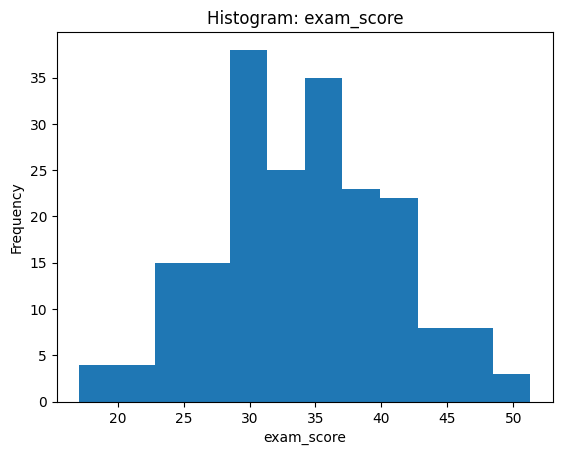

In [ ]:


df = pd.read_csv("student_exam_scores.csv")


num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Plot histograms
for col in num_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=12)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


### Distributions

In [ ]:

summary = df[num_cols].agg(["mean", "median", "std", "skew", "kurt"]).T
summary = summary.rename(columns={"kurt": "kurtosis"})
summary.round(3)


,mean,median,std,skew,kurtosis
hours_studied,6.326,6.15,3.227,0.117,-1.218
sleep_hours,6.622,6.70,1.497,-0.043,-1.295
attendance_percent,74.830,75.25,14.250,-0.073,-1.198
previous_scores,66.800,67.50,15.664,0.060,-1.220
exam_score,33.955,34.05,6.790,0.033,-0.346


### Box-Whisker Plots

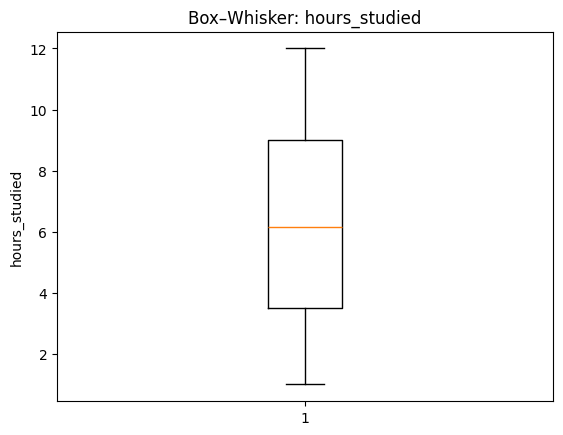

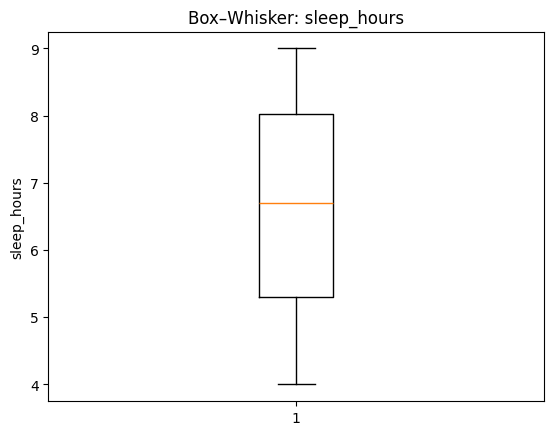

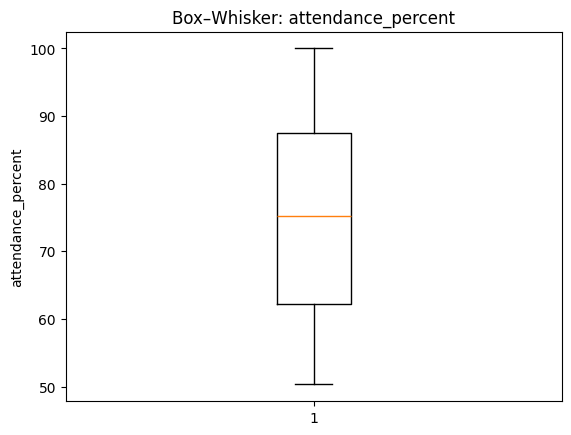

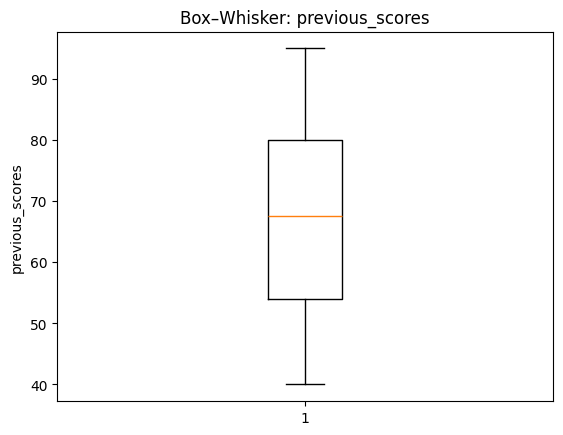

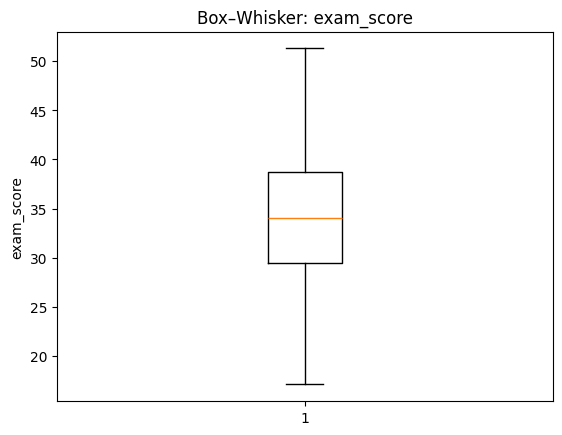

In [ ]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna(), vert=True)
    plt.title(f"Box–Whisker: {col}")
    plt.ylabel(col)
    plt.show()


### Violin Plots

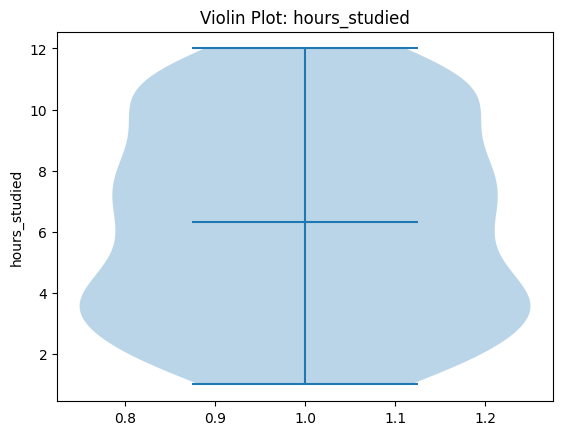

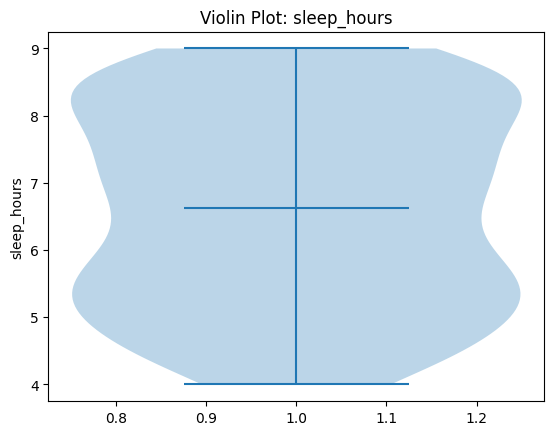

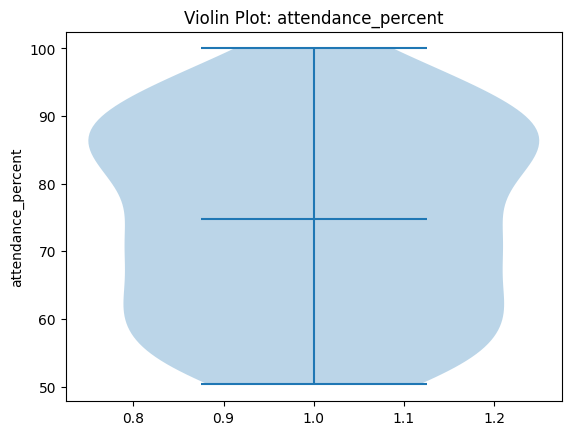

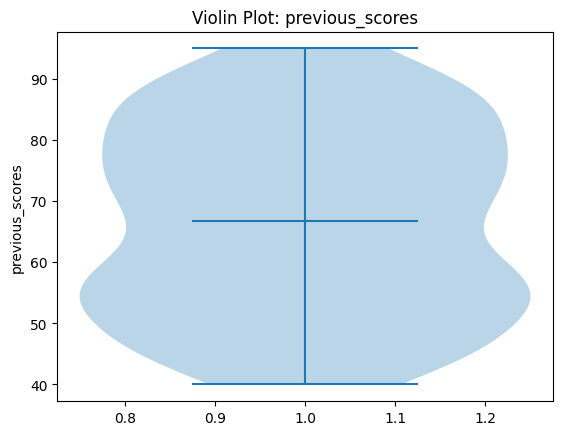

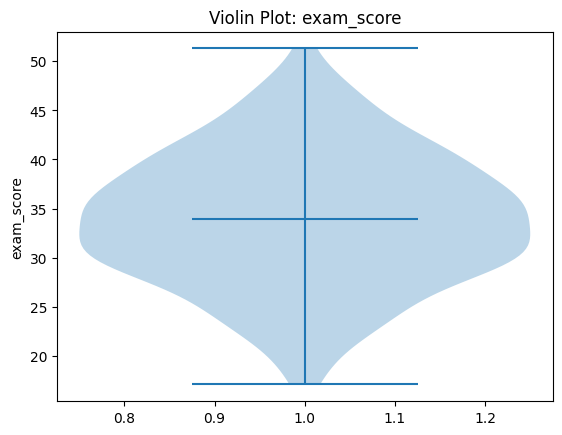

In [ ]:

for col in num_cols:
    plt.figure()
    plt.violinplot(df[col].dropna(), showmeans=True)
    plt.title(f"Violin Plot: {col}")
    plt.ylabel(col)
    plt.show()


## Data Quality & Cleaning

Instruction: Add a comment for each method

We used IQR to detect any potential outliers

In [ ]:
print(f"Missing values: {df.isnull().sum()}")

#Removing any duplicate IDs
duplicates = df.duplicated(subset=['student_id'])
if duplicates.any():
    print(f"Found {duplicates.sum()} duplicates Student IDs")
    df = df.drop_duplicates(subset=['student_id'], keep='first')
else:
    print("\nNo duplicate Student IDs found")

#IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n{col}:")
    print(f"Range: [{df[col].min():.2f}, {df[col].max():.2f}]")
    print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

Missing values: student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

No duplicate Student IDs found

hours_studied:
Range: [1.00, 12.00]
IQR bounds: [-4.75, 17.25]
Outliers: 0 (0.0%)

sleep_hours:
Range: [4.00, 9.00]
IQR bounds: [1.21, 12.11]
Outliers: 0 (0.0%)

attendance_percent:
Range: [50.30, 100.00]
IQR bounds: [24.36, 125.26]
Outliers: 0 (0.0%)

previous_scores:
Range: [40.00, 95.00]
IQR bounds: [15.00, 119.00]
Outliers: 0 (0.0%)

exam_score:
Range: [17.10, 51.30]
IQR bounds: [15.62, 52.62]
Outliers: 0 (0.0%)


## Handling Redundancy

### X-square Test

In [ ]:
df["attendance_level"] = pd.cut(
    df["attendance_percent"],
    bins=[0, 60, 80, 100],
    labels=["Low", "Medium", "High"]
)

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df["attendance_level"], df["sleep_hours"] > df["sleep_hours"].median())
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 0.3094069254279462
p-value: 0.8566691741739401


### Correlation Analysis

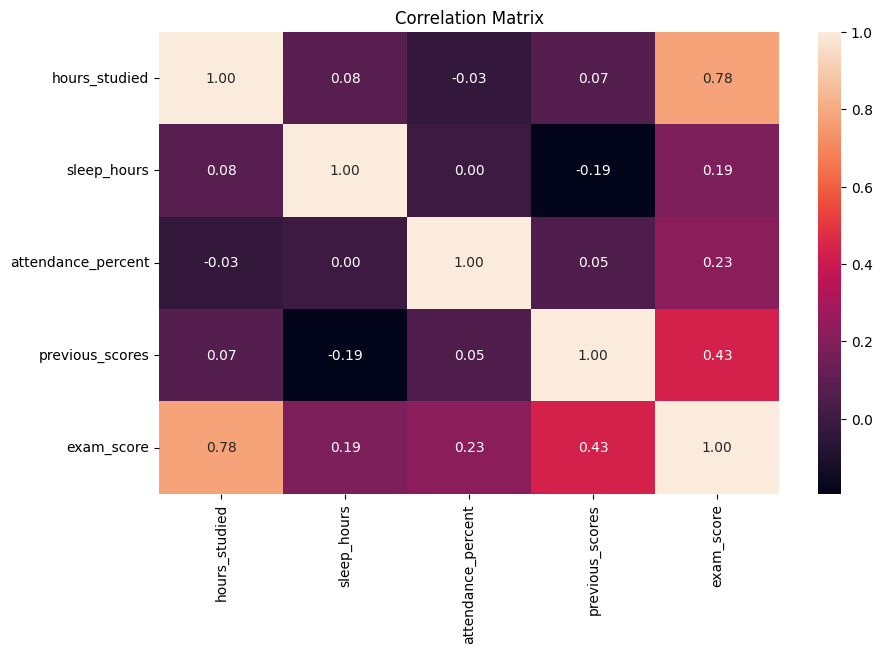

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ["hours_studied", "sleep_hours", "attendance_percent",
                "previous_scores", "exam_score"]

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Visual Exploration (scatter-plot matrix)

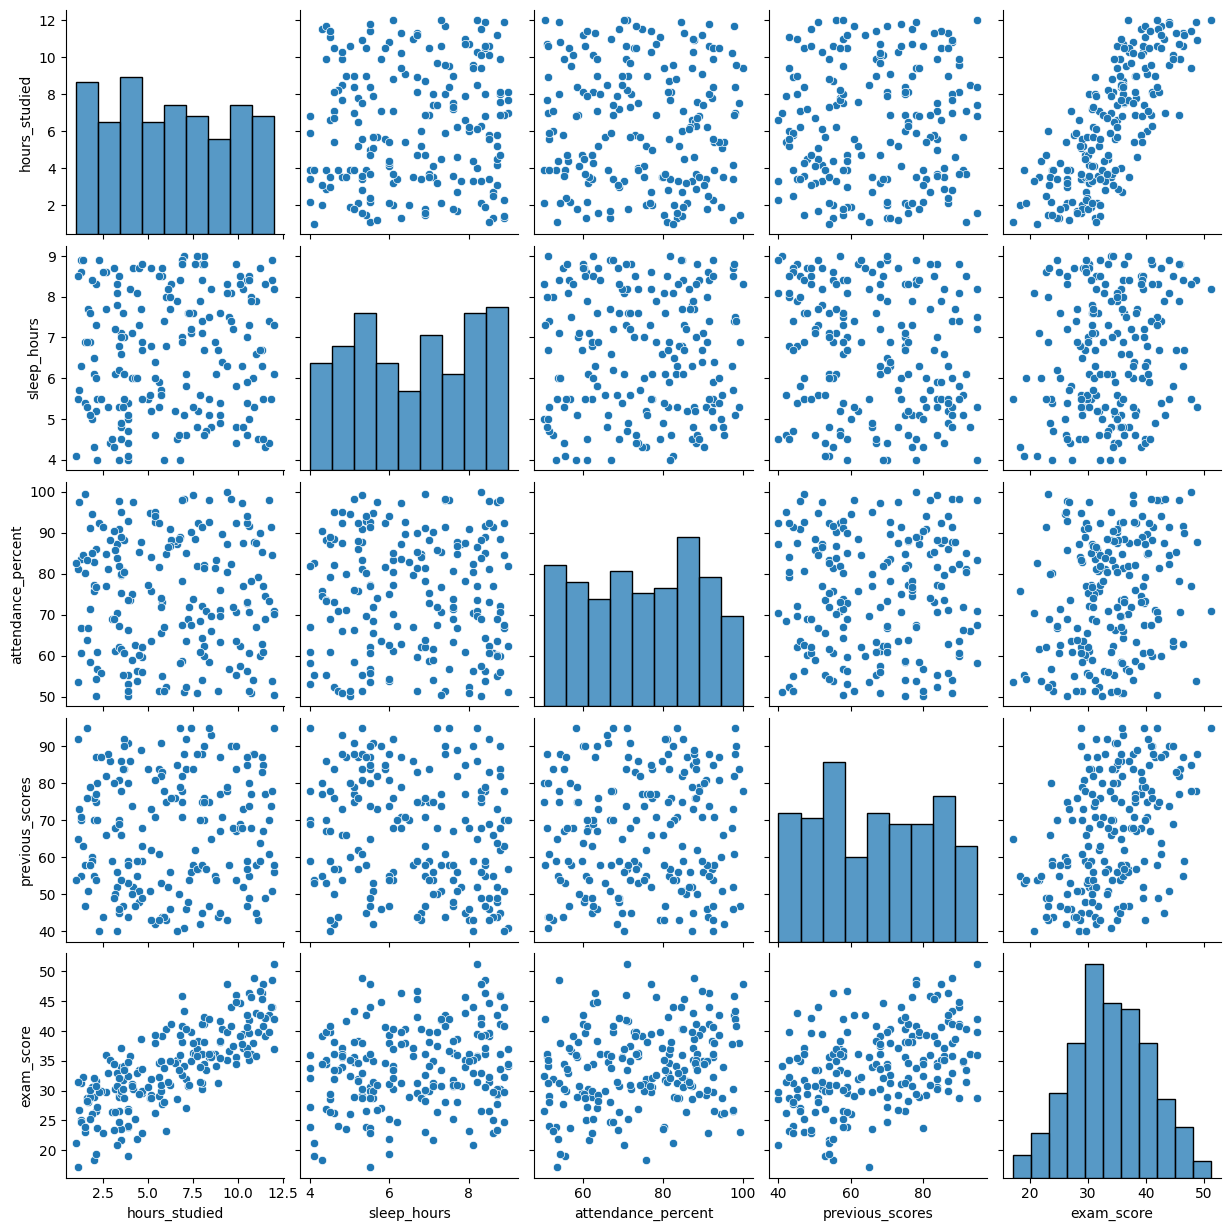

In [ ]:
sns.pairplot(df[numeric_cols])
plt.show()

## Dimensionality Reduction

### PCA

Explained Variance Ratio:
[0.30037987 0.26200627 0.2496514  0.18796247]

Cumulative Explained Variance:
[0.30037987 0.56238613 0.81203753 1.        ]


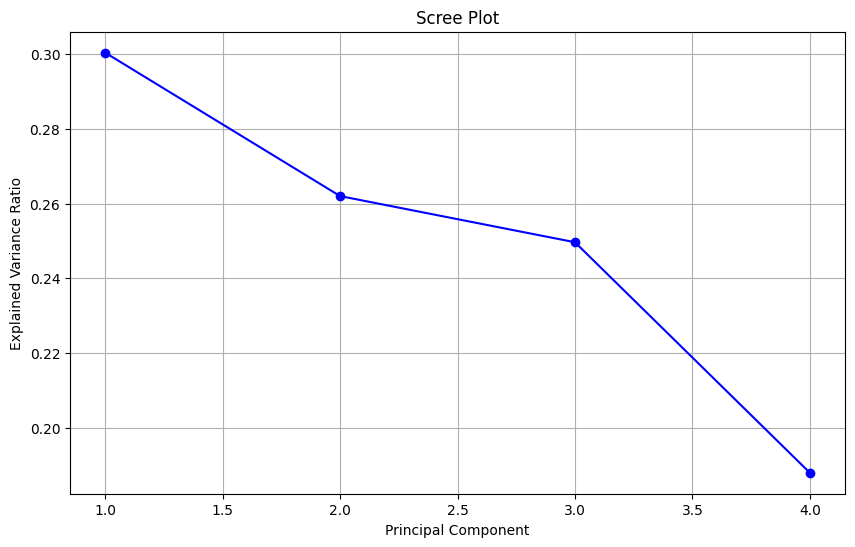

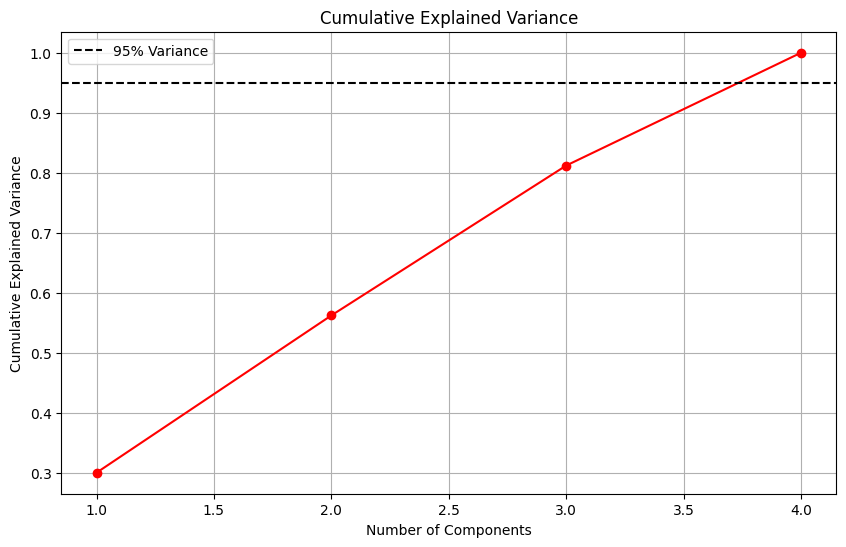


First few rows of PCA-transformed data:


,PC1,PC2,PC3,PC4
0,-2.044913,0.331528,0.258176,-0.151287
1,-1.536011,-1.168268,-0.831232,1.155291
2,0.150143,-0.055171,0.220503,1.755128
3,1.125141,-1.367736,0.805250,-0.714123
4,0.435880,0.578953,1.099397,-0.460928


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features_for_pca = ["hours_studied", "sleep_hours", "attendance_percent", "previous_scores"]
X = df[features_for_pca].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("\nCumulative Explained Variance:")
print(np.cumsum(pca.explained_variance_ratio_))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), 'ro-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.axhline(y=0.95, color='k', linestyle='--', label='95% Variance')
plt.legend()
plt.grid(True)
plt.show()

#Create DataFrame with principal components
pca_df = pd.DataFrame(
    data=X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)
print("\nFirst few rows of PCA-transformed data:")
display(pca_df.head())

## Discretization

In [ ]:
df['hours_studied_binned'] = pd.cut(
    df['hours_studied'],
    bins=[0, 3, 6, 10],
    labels=['Low', 'Medium', 'High']
)

df['sleep_hours_binned'] = pd.cut(
    df['sleep_hours'],
    bins=[0, 5, 7, 10],
    labels=['Low', 'Medium', 'High']
)

df['previous_scores_binned'] = pd.cut(
    df['previous_scores'],
    bins=[0, 60, 80, 100],
    labels=['Low', 'Medium', 'High']
)

percentile_33 = df['exam_score'].quantile(0.33)
percentile_67 = df['exam_score'].quantile(0.67)

df['exam_score_binned'] = pd.cut(
    df['exam_score'],
    bins=[0, percentile_33, percentile_67, 100],
    labels=['Low', 'Medium', 'High']
)

print("\nExam Score Binning:")
print(f"  Low: 0 - {percentile_33:.2f}")
print(f"  Medium: {percentile_33:.2f} - {percentile_67:.2f}")
print(f"  High: {percentile_67:.2f} - 100")

print("\nDistribution of discretized exam_score:")
print(df['exam_score_binned'].value_counts().sort_index())

print("\nSample of original vs discretized:")
print(df[['exam_score', 'exam_score_binned']].head(10))


Exam Score Binning:
  Low: 0 - 30.70
  Medium: 30.70 - 36.77
  High: 36.77 - 100

Distribution of discretized exam_score:
exam_score_binned
Low       68
Medium    66
High      66
Name: count, dtype: int64

Sample of original vs discretized:
   exam_score exam_score_binned
0        30.2               Low
1        25.0               Low
2        35.8            Medium
3        34.0            Medium
4        40.3              High
5        35.7            Medium
6        37.9              High
7        18.3               Low
8        34.7            Medium
9        24.7               Low


### Histogram of Discretized Attribute

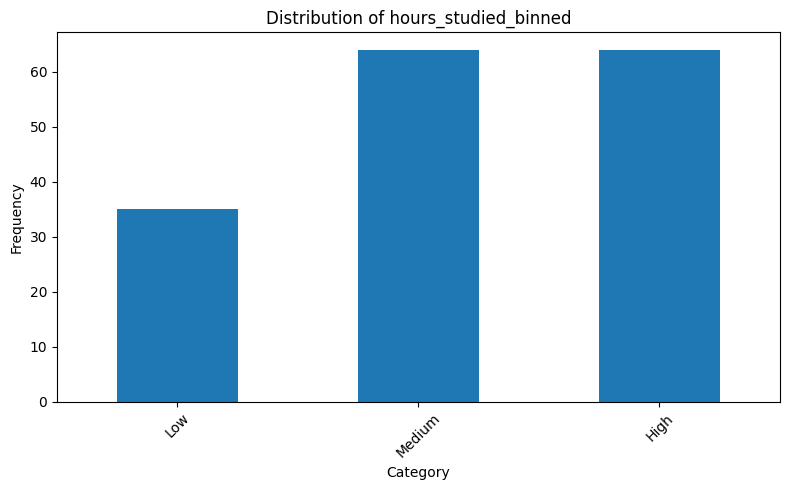

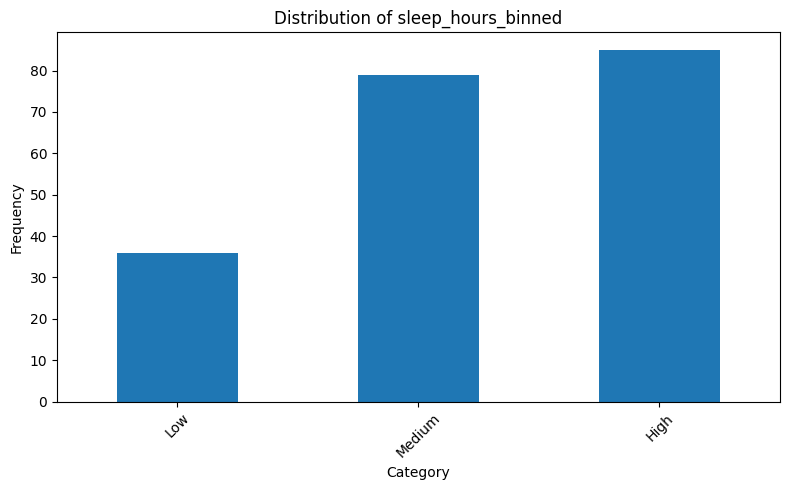

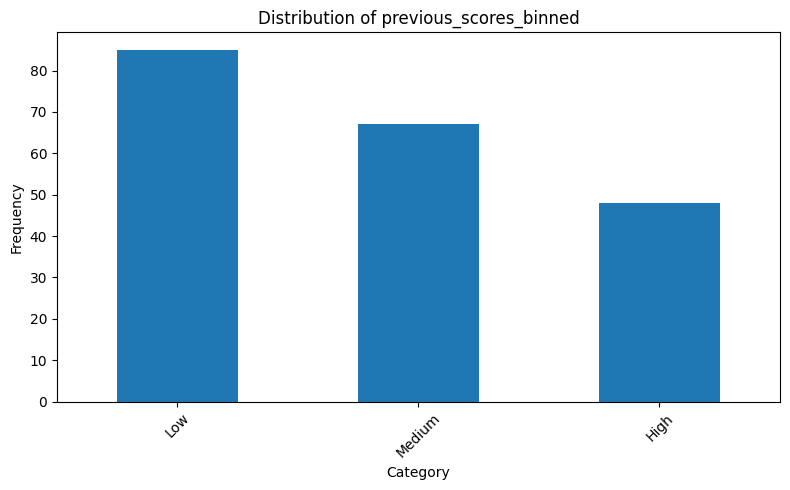

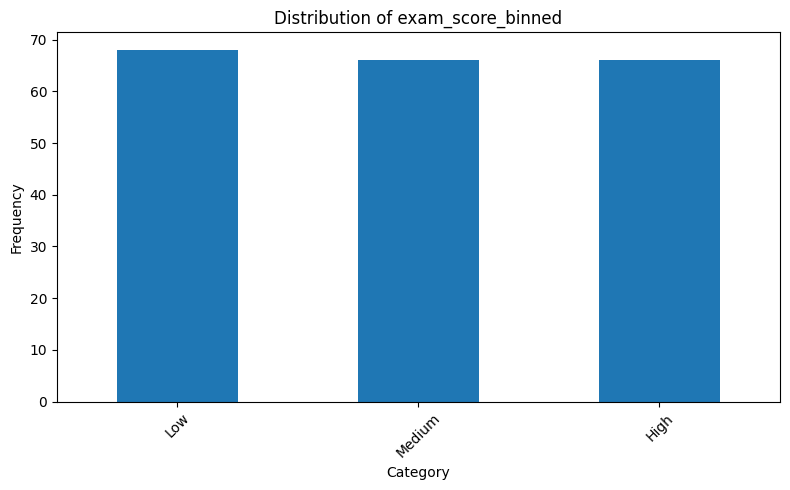

In [ ]:
discretized_cols = ['hours_studied_binned', 'sleep_hours_binned',
                   'previous_scores_binned', 'exam_score_binned']

for col in discretized_cols:
    plt.figure(figsize=(8, 5))
    df[col].value_counts().sort_index().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Category')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### X-square Test of Discretized Attributes

In [ ]:
discretized_pairs = [
    ('hours_studied_binned', 'exam_score_binned'),
    ('sleep_hours_binned', 'exam_score_binned'),
    ('previous_scores_binned', 'exam_score_binned'),
    ('hours_studied_binned', 'sleep_hours_binned'),
    ('attendance_level', 'exam_score_binned')
]

print("Chi-square Tests for Discretized Attributes:")

for col1, col2 in discretized_pairs:
    table = pd.crosstab(df[col1], df[col2])

    chi2, p, dof, expected = chi2_contingency(table)

    print(f"\n{col1} vs {col2}")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"p-value: {p:.4f}")
    print(f"Degrees of freedom: {dof}")

    if p < 0.05:
        print("Result: Significant relationship (p < 0.05)")
    else:
        print("Result: No significant relationship (p >= 0.05)")
    print("-" * 45)

Chi-square Tests for Discretized Attributes:

hours_studied_binned vs exam_score_binned
Chi-square statistic: 69.1150
p-value: 0.0000
Degrees of freedom: 4
Result: Significant relationship (p < 0.05)
---------------------------------------------

sleep_hours_binned vs exam_score_binned
Chi-square statistic: 6.4587
p-value: 0.1674
Degrees of freedom: 4
Result: No significant relationship (p >= 0.05)
---------------------------------------------

previous_scores_binned vs exam_score_binned
Chi-square statistic: 28.9594
p-value: 0.0000
Degrees of freedom: 4
Result: Significant relationship (p < 0.05)
---------------------------------------------

hours_studied_binned vs sleep_hours_binned
Chi-square statistic: 4.7738
p-value: 0.3113
Degrees of freedom: 4
Result: No significant relationship (p >= 0.05)
---------------------------------------------

attendance_level vs exam_score_binned
Chi-square statistic: 6.4183
p-value: 0.1700
Degrees of freedom: 4
Result: No significant relationship (p

### Visual Exploration (scatter-plot matrix) of Discretized Attributes

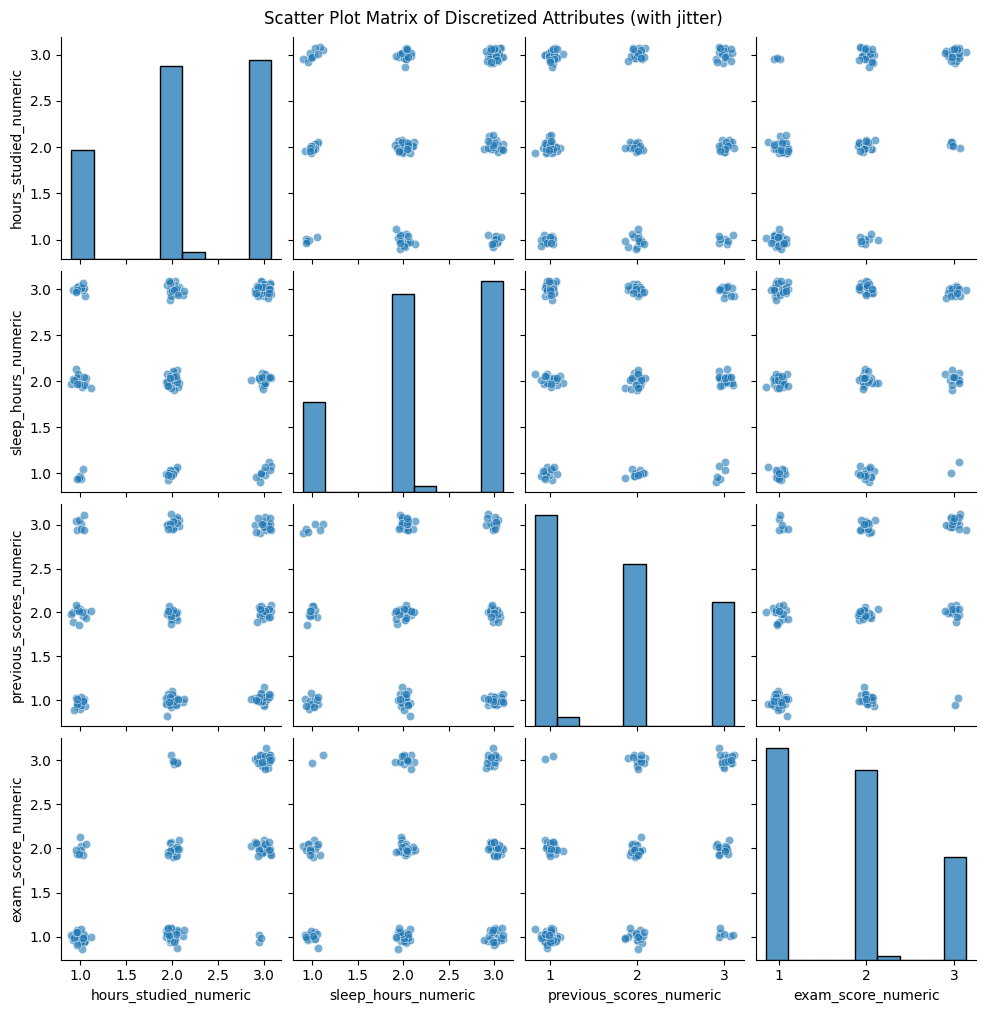

In [ ]:
df_numeric_discretized = df.copy()

category_mapping = {'Low': 1, 'Medium': 2, 'High': 3}

df_numeric_discretized['hours_studied_numeric'] = df['hours_studied_binned'].map(category_mapping)
df_numeric_discretized['sleep_hours_numeric'] = df['sleep_hours_binned'].map(category_mapping)
df_numeric_discretized['previous_scores_numeric'] = df['previous_scores_binned'].map(category_mapping)
df_numeric_discretized['exam_score_numeric'] = df['exam_score_binned'].map(category_mapping)

discretized_numeric_cols = ['hours_studied_numeric', 'sleep_hours_numeric',
                           'previous_scores_numeric', 'exam_score_numeric']

df_numeric_discretized[discretized_numeric_cols] = df_numeric_discretized[discretized_numeric_cols].astype(float)

# Drop any NaN values
df_clean = df_numeric_discretized[discretized_numeric_cols].dropna()

# Add jitter to make overlapping points visible
df_jittered = df_clean + np.random.normal(0, 0.05, df_clean.shape)

sns.pairplot(df_jittered,
             diag_kind='hist',
             plot_kws={'alpha': 0.6})
plt.suptitle('Scatter Plot Matrix of Discretized Attributes (with jitter)', y=1.01)
plt.show()


## Feature Selection/Generation

### Select Features

In [ ]:
# Select numeric features for clustering
selected_features = ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']
X = df[selected_features].copy()
print(f"Selected features: {selected_features}")
print(f"Shape: {X.shape}")

Selected features: ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']
Shape: (200, 5)


### Generate Features

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=selected_features)
print("Features standardized")
print(X_scaled.head())

Features standardized
   hours_studied  sleep_hours  attendance_percent  previous_scores  exam_score
0       0.520154     1.458426           -0.192061        -1.395230   -0.554444
1      -1.561083     1.324503           -0.994074        -0.755216   -1.322249
2      -0.722376     1.056656           -0.079498         1.228827    0.272423
3      -0.877692    -1.220042            1.426035        -0.051201    0.006644
4       0.861850    -0.148655            1.053170         0.268806    0.936870


# Generate Clusters

## K-means

K-means clustering completed with k=3
Cluster distribution:
0    56
1    55
2    89
Name: count, dtype: int64


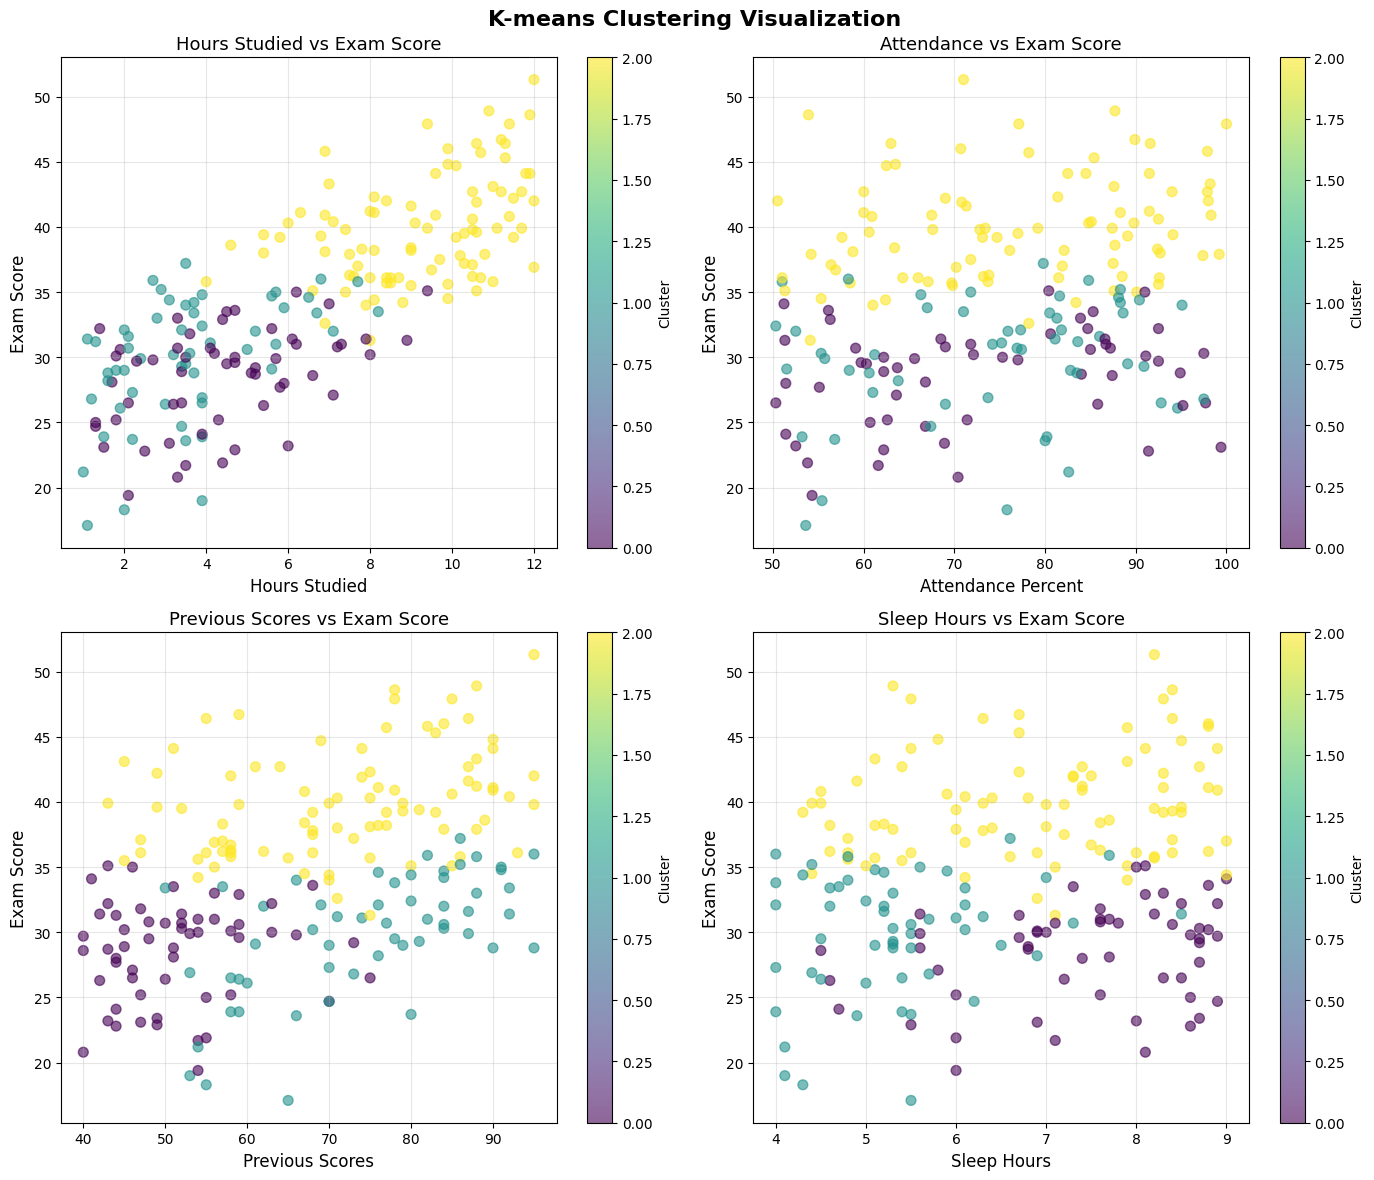


Cluster Summary Statistics:

Cluster 0 (n=56):
  Hours Studied: 4.44 ± 2.02
  Sleep Hours: 7.45 ± 1.22
  Attendance: 72.61% ± 15.04
  Previous Scores: 51.27 ± 8.51
  Exam Score: 28.49 ± 3.79

Cluster 1 (n=55):
  Hours Studied: 3.58 ± 1.80
  Sleep Hours: 5.34 ± 0.98
  Attendance: 74.01% ± 13.55
  Previous Scores: 74.80 ± 12.56
  Exam Score: 29.90 ± 4.67

Cluster 2 (n=89):
  Hours Studied: 9.21 ± 1.91
  Sleep Hours: 6.89 ± 1.42
  Attendance: 76.73% ± 14.07
  Previous Scores: 71.63 ± 13.99
  Exam Score: 39.90 ± 4.11


In [ ]:
from sklearn.cluster import KMeans


# Apply K-means clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['kmeans_cluster'] = kmeans_labels

print(f"K-means clustering completed with k=3")
print(f"Cluster distribution:\n{pd.Series(kmeans_labels).value_counts().sort_index()}")

# Visualize K-means clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('K-means Clustering Visualization', fontsize=16, fontweight='bold')

# Plot 1: hours_studied vs exam_score
scatter1 = axes[0, 0].scatter(df['hours_studied'], df['exam_score'],
                               c=kmeans_labels, cmap='viridis', alpha=0.6, s=50)
axes[0, 0].set_xlabel('Hours Studied', fontsize=12)
axes[0, 0].set_ylabel('Exam Score', fontsize=12)
axes[0, 0].set_title('Hours Studied vs Exam Score', fontsize=13)
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster')

# Plot 2: attendance_percent vs exam_score
scatter2 = axes[0, 1].scatter(df['attendance_percent'], df['exam_score'],
                               c=kmeans_labels, cmap='viridis', alpha=0.6, s=50)
axes[0, 1].set_xlabel('Attendance Percent', fontsize=12)
axes[0, 1].set_ylabel('Exam Score', fontsize=12)
axes[0, 1].set_title('Attendance vs Exam Score', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0, 1], label='Cluster')

# Plot 3: previous_scores vs exam_score
scatter3 = axes[1, 0].scatter(df['previous_scores'], df['exam_score'],
                               c=kmeans_labels, cmap='viridis', alpha=0.6, s=50)
axes[1, 0].set_xlabel('Previous Scores', fontsize=12)
axes[1, 0].set_ylabel('Exam Score', fontsize=12)
axes[1, 0].set_title('Previous Scores vs Exam Score', fontsize=13)
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0], label='Cluster')

# Plot 4: sleep_hours vs exam_score
scatter4 = axes[1, 1].scatter(df['sleep_hours'], df['exam_score'],
                               c=kmeans_labels, cmap='viridis', alpha=0.6, s=50)
axes[1, 1].set_xlabel('Sleep Hours', fontsize=12)
axes[1, 1].set_ylabel('Exam Score', fontsize=12)
axes[1, 1].set_title('Sleep Hours vs Exam Score', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=axes[1, 1], label='Cluster')

plt.tight_layout()
plt.show()

# Cluster summary statistics
print("\nCluster Summary Statistics:")
print("="*60)
for cluster in range(3):
    cluster_data = df[df['kmeans_cluster'] == cluster]
    print(f"\nCluster {cluster} (n={len(cluster_data)}):")
    print(f"  Hours Studied: {cluster_data['hours_studied'].mean():.2f} ± {cluster_data['hours_studied'].std():.2f}")
    print(f"  Sleep Hours: {cluster_data['sleep_hours'].mean():.2f} ± {cluster_data['sleep_hours'].std():.2f}")
    print(f"  Attendance: {cluster_data['attendance_percent'].mean():.2f}% ± {cluster_data['attendance_percent'].std():.2f}")
    print(f"  Previous Scores: {cluster_data['previous_scores'].mean():.2f} ± {cluster_data['previous_scores'].std():.2f}")
    print(f"  Exam Score: {cluster_data['exam_score'].mean():.2f} ± {cluster_data['exam_score'].std():.2f}")

## Hierarchical

Hierarchical clustering completed with 3 clusters
Cluster distribution:
0    97
1    58
2    45
Name: count, dtype: int64


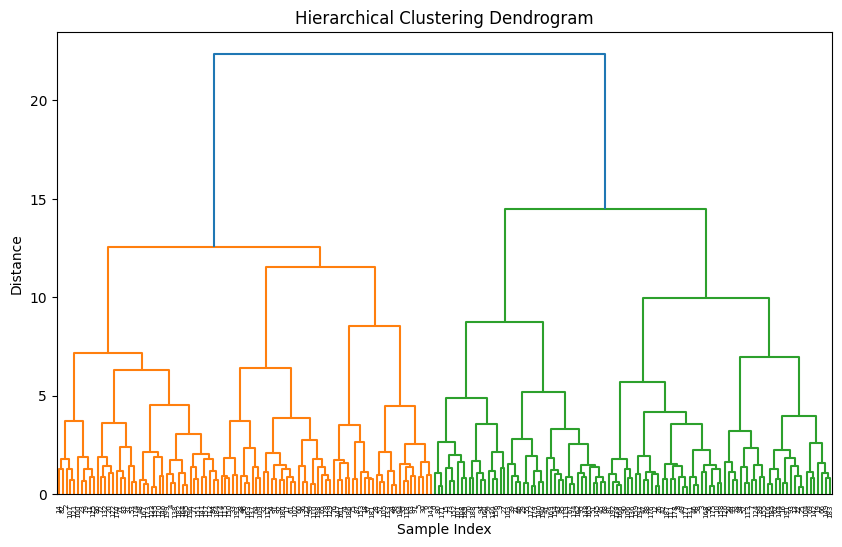

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Apply hierarchical clustering with 3 clusters
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['hierarchical_cluster'] = hierarchical_labels

print(f"Hierarchical clustering completed with 3 clusters")
print(f"Cluster distribution:\n{pd.Series(hierarchical_labels).value_counts().sort_index()}")

# Create dendrogram
linkage_matrix = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Evaluation of Clusters

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Evaluate K-means clusters
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)

print("K-means Clustering Evaluation:")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_db:.4f}")
print(f"Calinski-Harabasz Index: {kmeans_ch:.4f}")
print()

# Evaluate Hierarchical clusters
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
hierarchical_db = davies_bouldin_score(X_scaled, hierarchical_labels)
hierarchical_ch = calinski_harabasz_score(X_scaled, hierarchical_labels)

print("Hierarchical Clustering Evaluation:")
print(f"Silhouette Score: {hierarchical_silhouette:.4f}")
print(f"Davies-Bouldin Index: {hierarchical_db:.4f}")
print(f"Calinski-Harabasz Index: {hierarchical_ch:.4f}")

K-means Clustering Evaluation:
Silhouette Score: 0.2209
Davies-Bouldin Index: 1.4524
Calinski-Harabasz Index: 64.8582

Hierarchical Clustering Evaluation:
Silhouette Score: 0.1850
Davies-Bouldin Index: 1.4885
Calinski-Harabasz Index: 54.0493


## <center> REFERENCES </center>
List resources (book, internet page, etc.) that you used to complete this challenge.



*   Scikit-learn: Machine Learning in Python. Pedregosa et al., JMLR 12, pp. 2825-2830, 2011
*   Python Data Science Handbook by Jake VanderPlas


*   Pang-Ning Tan, Michael Steinbach, Anuj Karpatne, Vipin Kumar. Introduction to Data
Mining, 2nd Ed., Morgan Kaufmann, 2011








